In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
!ls

Linear_Regression.ipynb         Real_World_Classification.ipynb
Logistic_Regression.ipynb       data
README.md                       model


In [4]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

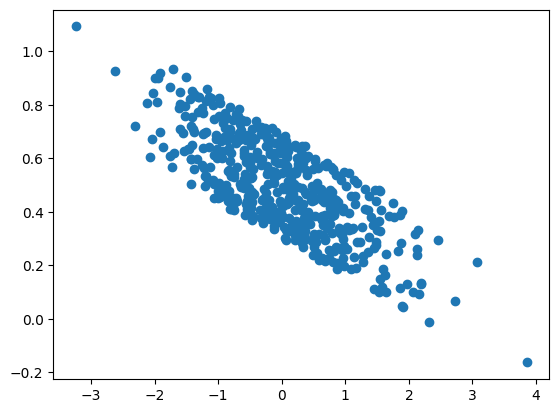

In [5]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [11]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 0.08822499761459238, Val loss:0.08344253861678508
100. Training loss: 0.024461533163063466, Val loss:0.022730598385935274
150. Training loss: 0.01505434188857738, Val loss:0.013961184271627122
200. Training loss: 0.013664791563666536, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002818
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964214, Val loss:0.012579546976647177
500. Training loss: 0.013423625043327496, Val loss:0.012579881257862182


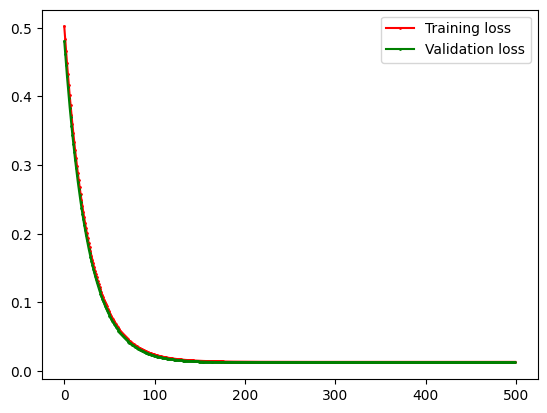

In [12]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [13]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [14]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013355229539356037,
 'MAE': 0.10095149880498928,
 'RMSE': 0.11556482829717715,
 'R-squared': 0.5689997481843656}

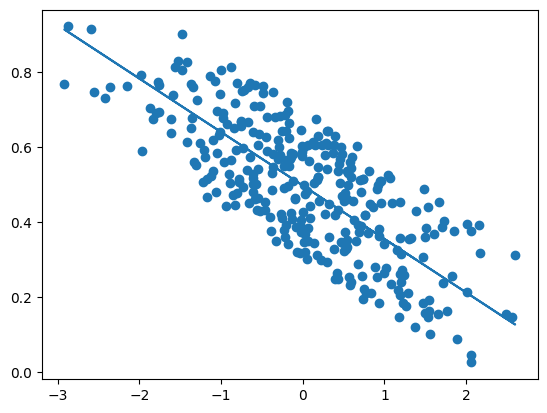

In [15]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()

50. Training loss: 0.013423623061455567, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987135, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


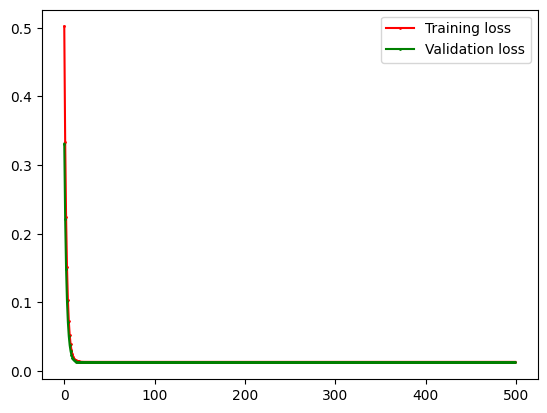

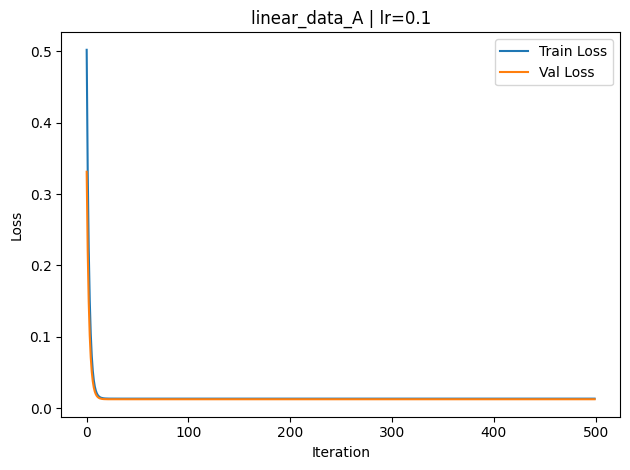

=== linear_data_A | lr=0.1 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
50. Training loss: 0.08822499761459238, Val loss:0.08344253861678508
100. Training loss: 0.024461533163063466, Val loss:0.022730598385935274
150. Training loss: 0.01505434188857738, Val loss:0.013961184271627122
200. Training loss: 0.013664791563666536, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002818
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964214, Val loss:0.012579546976647177
500. Training loss: 0.013423625043327496, Val loss:0.012579881257862182


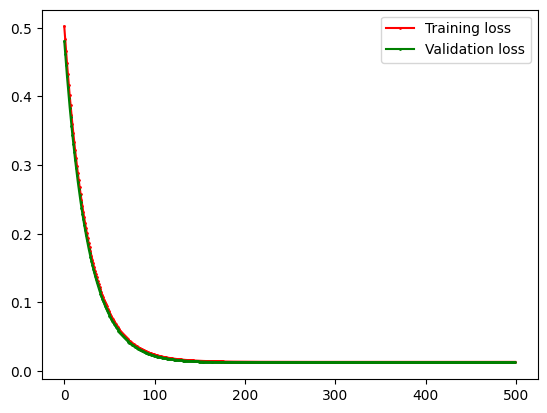

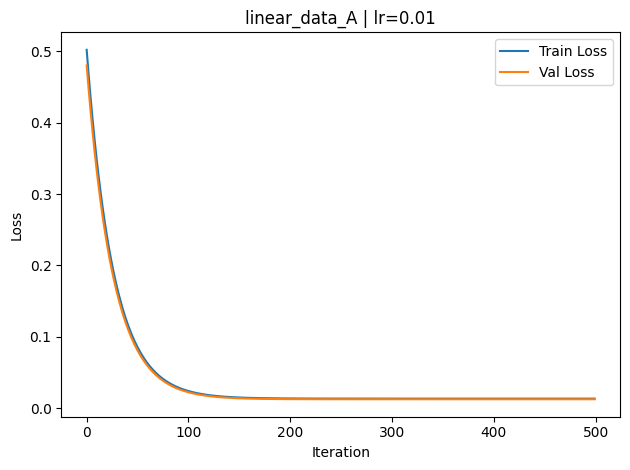

=== linear_data_A | lr=0.01 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
50. Training loss: 0.4189849252743381, Val loss:0.41420880497204005
100. Training loss: 0.34884281364937, Val loss:0.3445251797643867
150. Training loss: 0.2908358402579774, Val loss:0.2869133468711063
200. Training loss: 0.24286379534660618, Val loss:0.23928338706190333
250. Training loss: 0.20319008395293753, Val loss:0.19990713434668128
300. Training loss: 0.17037874765339447, Val loss:0.1673555525025328
350. Training loss: 0.14324239869173927, Val loss:0.14044695514816508
400. Training loss: 0.12079917484937544, Val loss:0.11820419110090796
450. Training loss: 0.10223715148116816, Val loss:0.09981924222927957
500. Training loss: 0.08688491828078362, Val loss:0.08462395006505137


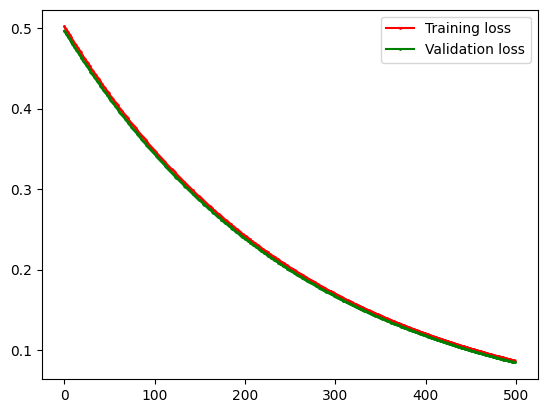

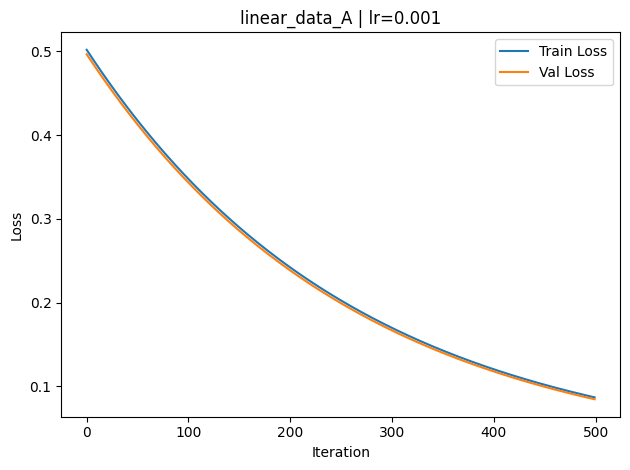

=== linear_data_A | lr=0.001 ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836
50. Training loss: 0.2147779602976193, Val loss:0.20128111574984847
100. Training loss: 0.21477795969579408, Val loss:0.201281435433012
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080995
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


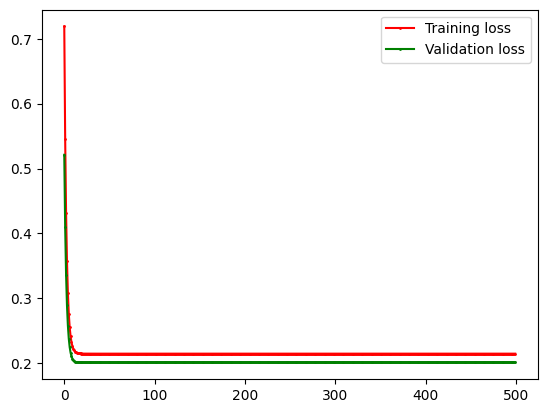

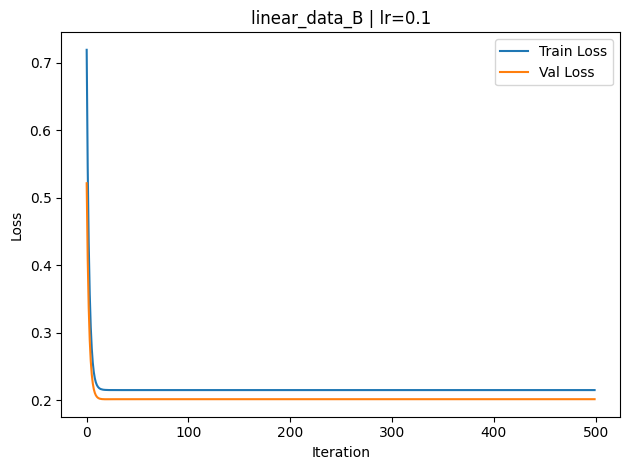

=== linear_data_B | lr=0.1 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
50. Training loss: 0.2920213425997664, Val loss:0.27026114086461656
100. Training loss: 0.2261837940753283, Val loss:0.2101879308116208
150. Training loss: 0.2164640141651331, Val loss:0.2021155812609517
200. Training loss: 0.21502743867502366, Val loss:0.20122361991141446
250. Training loss: 0.21481490508468085, Val loss:0.20120482979710497
300. Training loss: 0.21478343493349927, Val loss:0.20124452118342356
350. Training loss: 0.21477877162933795, Val loss:0.20126634873684507
400. Training loss: 0.21477808016505961, Val loss:0.20127557772119783
450. Training loss: 0.21477797757871428, Val loss:0.20127920153421994
500. Training loss: 0.2147779623514954, Val loss:0.20128058874123028


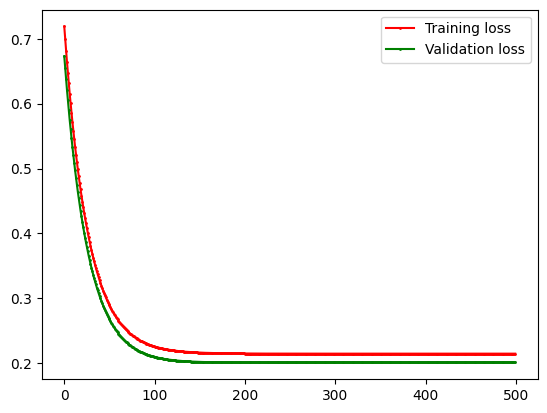

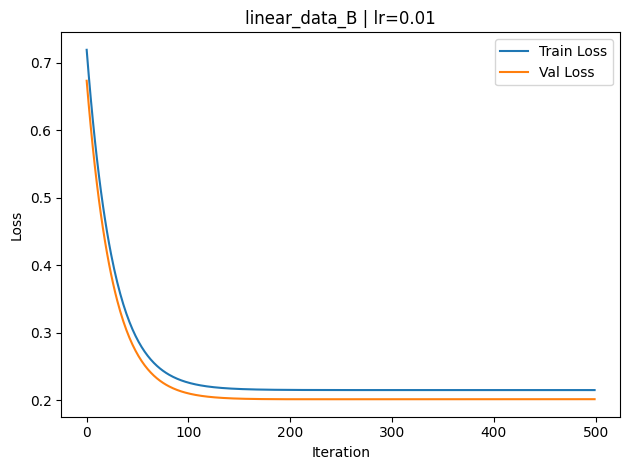

=== linear_data_B | lr=0.01 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370381
150. Training loss: 0.5011005997675118, Val loss:0.4761621599409662
200. Training loss: 0.4516056474010013, Val loss:0.4277683253433775
250. Training loss: 0.410669175541332, Val loss:0.3878209660417228
300. Training loss: 0.37681081233745717, Val loss:0.35485234230464696
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083345
450. Training loss: 0.3064845362852951, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


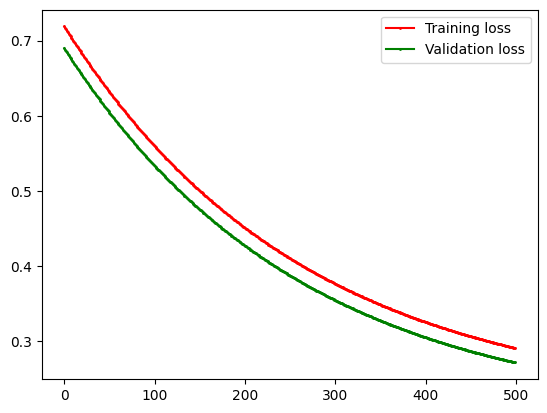

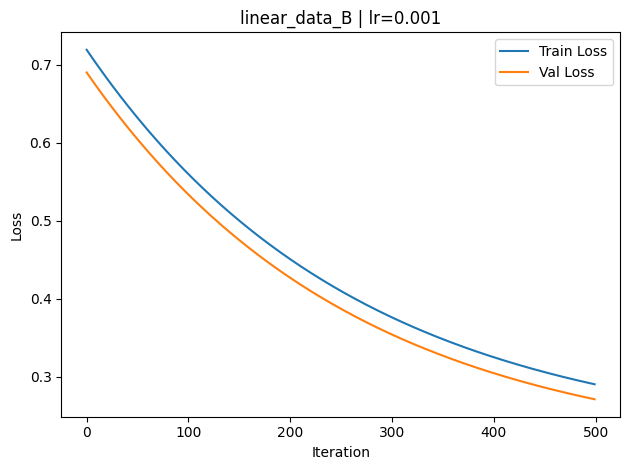

=== linear_data_B | lr=0.001 ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011
50. Training loss: 0.0131818971313023, Val loss:0.013771656751385359
100. Training loss: 0.013181896123422132, Val loss:0.013771595669720499
150. Training loss: 0.013181896123422132, Val loss:0.01377159566917531
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


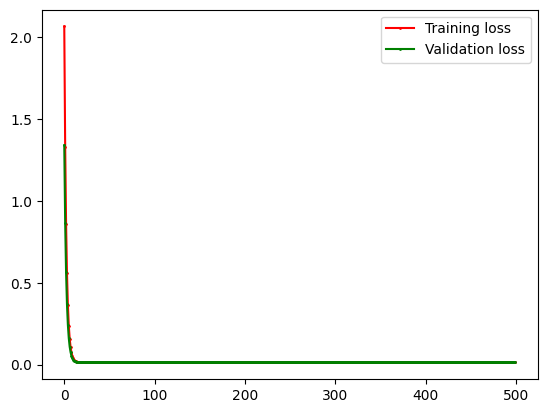

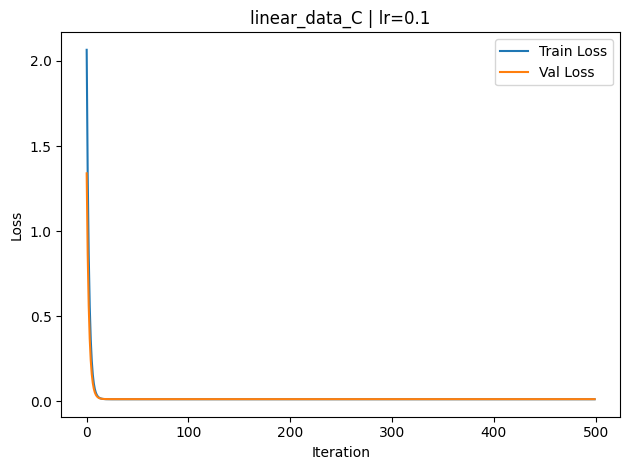

=== linear_data_C | lr=0.1 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
50. Training loss: 0.3016776572102273, Val loss:0.2940364008397446
100. Training loss: 0.05230128191456955, Val loss:0.052286225702638654
150. Training loss: 0.01850585072652704, Val loss:0.01917541216232357
200. Training loss: 0.013908983721033271, Val loss:0.01456489629791812
250. Training loss: 0.01328152198797338, Val loss:0.01389971244927915
300. Training loss: 0.01319558969139006, Val loss:0.01379609653511309
350. Training loss: 0.013183783898695744, Val loss:0.013777427806772768
400. Training loss: 0.013182157103470477, Val loss:0.013773277022245267
450. Training loss: 0.013181932299897786, Val loss:0.013772140690770072
500. Training loss: 0.013181901150900588, Val loss:0.013771782558303797


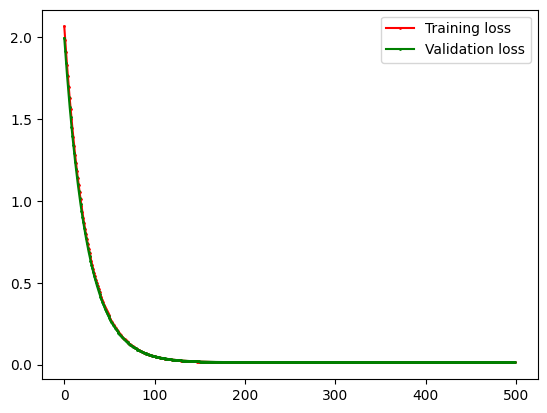

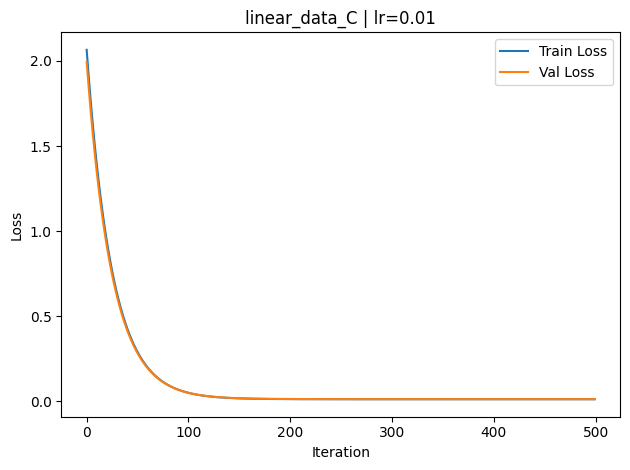

=== linear_data_C | lr=0.01 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
50. Training loss: 1.7022307356186883, Val loss:1.7043995619027572
100. Training loss: 1.398099093422373, Val loss:1.4007211470145513
150. Training loss: 1.1487734111234604, Val loss:1.1516658664027397
200. Training loss: 0.9443693636081104, Val loss:0.9473976449419805
250. Training loss: 0.7767867515803094, Val loss:0.7798533335010579
300. Training loss: 0.6393871949572306, Val loss:0.6424228534106733
350. Training loss: 0.5267301015086951, Val loss:0.5296870971374621
400. Training loss: 0.43435636502919184, Val loss:0.4372031470837644
450. Training loss: 0.35861115740443494, Val loss:0.36132826251110783
500. Training loss: 0.2964987427402306, Val loss:0.299075630842221


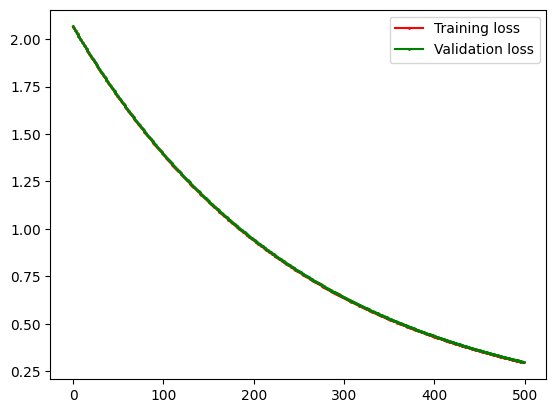

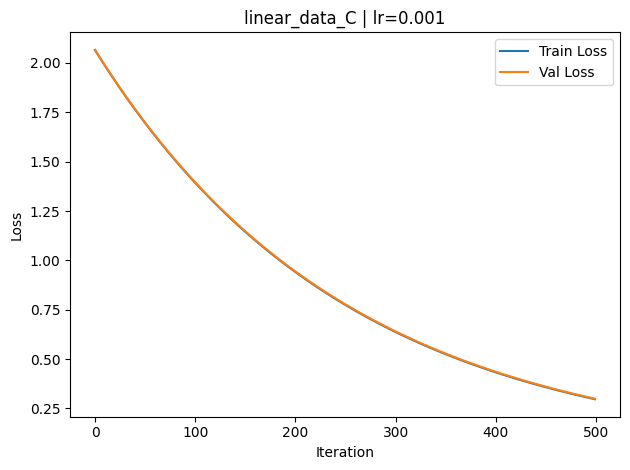

=== linear_data_C | lr=0.001 ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994
50. Training loss: 0.08238685177710689, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
250. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
300. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
350. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
400. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
450. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
500. Training loss: 0.08238685077138833, Val loss:0.08607247293234568


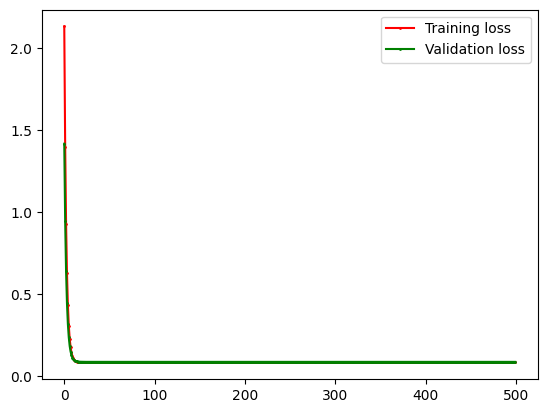

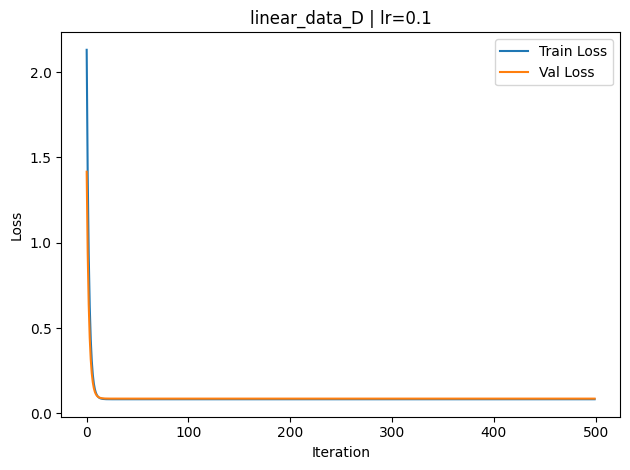

=== linear_data_D | lr=0.1 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
50. Training loss: 0.3703643487722049, Val loss:0.36868495639833204
100. Training loss: 0.12143459698593069, Val loss:0.1255385955779745
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594522, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529506
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.08238688687299428, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416796


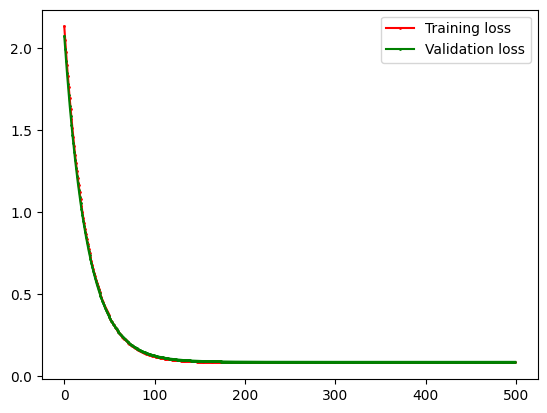

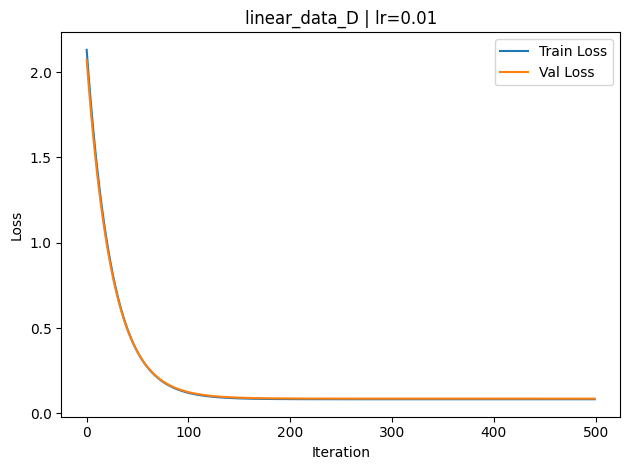

=== linear_data_D | lr=0.01 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716
50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.4648524964143852, Val loss:1.4770554865390986
150. Training loss: 1.2159645145907356, Val loss:1.2278106296911493
200. Training loss: 1.0119199428934706, Val loss:1.0233353741451865
250. Training loss: 0.8446325767970521, Val loss:0.8555746535033422
300. Training loss: 0.707475524484535, Val loss:0.71792454665939
350. Training loss: 0.5950176249327075, Val loss:0.6049705693586137
400. Training loss: 0.50280751484024, Val loss:0.5122732093945561
450. Training loss: 0.4271967232656893, Val loss:0.43619216922708653
500. Training loss: 0.3651947340371162, Val loss:0.3737423235472047


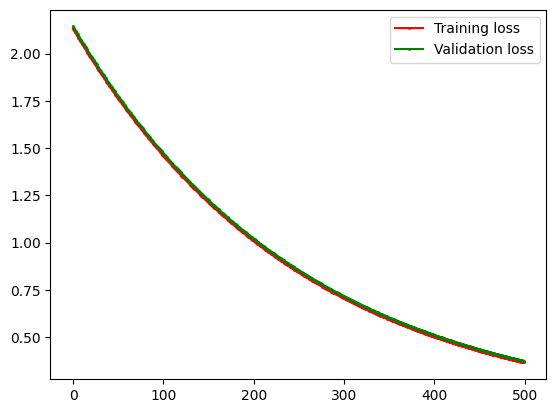

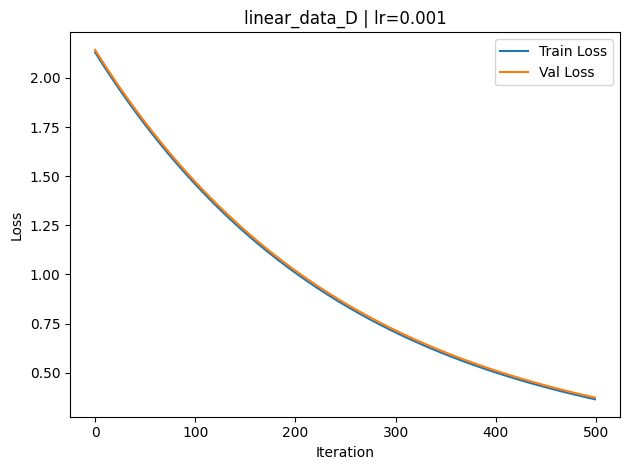

=== linear_data_D | lr=0.001 ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


In [16]:
import matplotlib.pyplot as plt
from model.linear_model import LinearModel
from model.metrics import MSE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import *

seed = 42
learning_rates = [0.1, 0.01, 0.001]

for dataset_name in ['linear_data_A', 'linear_data_B', 'linear_data_C', 'linear_data_D']:
    loaded_data = np.load(f'data/linear_data/{dataset_name}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    dim = X.shape[1] - 1

    for lr in learning_rates:
        np.random.seed(seed)
        X_train, y_train, X_val, y_val = get_train_val(X, y)
        model = LinearModel(dim, True, MSE, MSE_grad)
        model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

        # Use model.train_losses and model.val_losses directly
        plt.figure()
        plt.plot(model.train_losses, label='Train Loss')
        plt.plot(model.val_losses, label='Val Loss')
        plt.title(f'{dataset_name} | lr={lr}')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Evaluation (1b)
        y_val_pred = model.predict(X_val)
        evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred,
                                   title=f'{dataset_name} | lr={lr}')

In [ ]:
l